# UNAD - Analisis de Datos

## John Alejandro Ceballos Castaño
## Predicción de Red Wine Quality con Arboles de Decisión

### Pasos de la Actividad

1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.
2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario
3. Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características
4. Dividir el dataset en Train y Test para evaluar correctamente el modelo
5. Entrenar el modelo configurando los diferentes hiperparámetros
6. Evaluar el desempeño del modelo en el conjunto de Test con métricas como precisión, recall, F1-score, etc
7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo.
8. Interpretar, analizar y documentar los resultados obtenidos

### 1. Realizar un análisis exploratorio de los datos para identificar relaciones entre variables, valores atípicos, tendencias, etc.

In [2]:
#Cargar las librerias necesarias

import pandas as pd # Manejo y análisis de estructuras de datos
import numpy as np # Cálculo numérico y el análisis de datos
import seaborn as sns # Creación gráficos estadísticos
import matplotlib.pyplot as plt # Creación de gráficos en dos dimensiones

# librerías de para implementar modelos de ciencia de datos
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [3]:
# lectura de datos en Python y lo cargamos en la variable Datos

Datos = pd.read_csv('C:/Users/Alejandro/Documents/MEGA/UNAD/Periodo 6/Analisis de Datos/Tarea 3/Red Wine Quality/winequality-red.csv')

In [4]:
# Realizamos lectura de los Datos para el análisis exploratorio

Datos.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [5]:
# Descripción de los datos
Datos.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [13]:
#Identificación de Columnas y Filas

Datos.shape

(1599, 12)

In [10]:
#Identificación de Datos Faltante

Datos.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

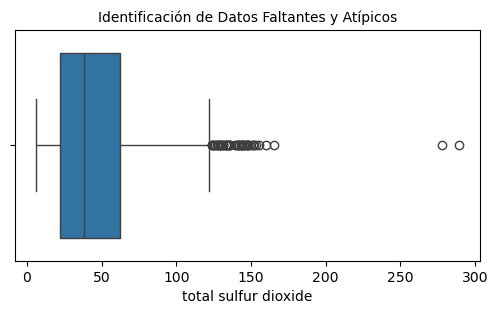

In [17]:
#Identificación de Valores Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['total sulfur dioxide'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

Text(0.5, 1.0, 'Identificación de Datos Faltantes y Atípicos')

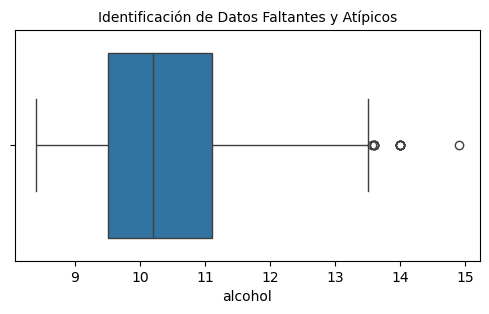

In [22]:
#Identificación de Valores Atípicos

plt.figure(figsize=(6, 3))
sns.boxplot(x=Datos['alcohol'])
plt.title('Identificación de Datos Faltantes y Atípicos', fontsize=10 )

(array([ 10.,   0.,  53.,   0., 624.,   0., 626.,   0., 192.,  16.]),
 array([3. , 3.5, 4. , 4.5, 5. , 5.5, 6. , 6.5, 7. , 7.5, 8. ]),
 <BarContainer object of 10 artists>)

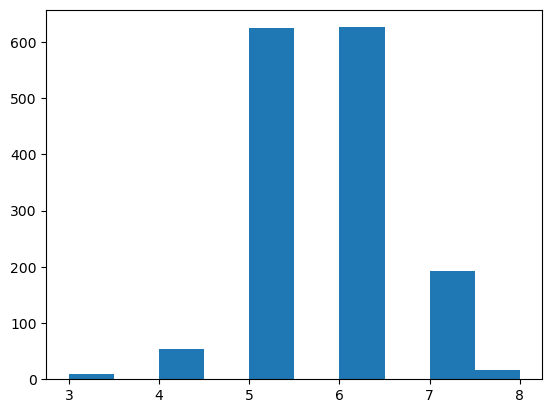

In [112]:
plt.hist(Datos.quality)

2. Preprocesar los datos limpiándolos, tratando valores faltantes y transformándolos según sea necesario

In [23]:
#Revisión del tipo de datos y datos faltantes

Datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [25]:
#Revisión de datos faltantes

print("Cantidad de Registros con cero en Calidad: ",Datos['quality'].isin([0]).sum())
print("Cantidad de Registros con cero en Alcohol: ",Datos['alcohol'].isin([0]).sum())
print("Cantidad de Registros con cero en Densidad: ",Datos['density'].isin([0]).sum())
print("Cantidad de Registros con cero en Acidez fija: ",Datos['fixed acidity'].isin([0]).sum())
print("")
print("No hay informacion faltante o campos vacios en el Dataset")

Cantidad de Registros con cero en Calidad:  0
Cantidad de Registros con cero en Alcohol:  0
Cantidad de Registros con cero en Densidad:  0
Cantidad de Registros con cero en Acidez fija:  0

No hay informacion faltante o campos vacios en el Dataset


In [51]:
#Conteo de Datos Atípicos

nivel_minimo=0
nivel_maximo=120
Total_Atipicos=((Datos['total sulfur dioxide']<nivel_minimo)|(Datos['total sulfur dioxide']>nivel_maximo)).sum()
print("El total de datos atípicos para Presion Arterial es {}".format(Total_Atipicos))

El total de datos atípicos para Presion Arterial es 34


In [52]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['total sulfur dioxide']<nivel_maximo)&(Datos['total sulfur dioxide']>nivel_minimo)]

In [53]:
Total_Atipicos=((Datos['total sulfur dioxide']<nivel_minimo)|(Datos['total sulfur dioxide']>nivel_maximo)).sum()
print("El total de datos atípicos es {}".format(Total_Atipicos))

El total de datos atípicos es 0


In [46]:
#Conteo de Datos Atípicos

nivel_minimo1=5
nivel_maximo1=13.5
Total_Atipicos=((Datos['alcohol']<nivel_minimo1)|(Datos['alcohol']>nivel_maximo1)).sum()
print("El total de datos atípicos para colesterol es {}".format(Total_Atipicos))

El total de datos atípicos para colesterol es 13


In [47]:
# Filtra Datos Atípicos

Datos=Datos[(Datos['alcohol']<nivel_maximo1)&(Datos['alcohol']>nivel_minimo1)]

In [48]:
Total_Atipicos=((Datos['alcohol']<nivel_minimo1)|(Datos['alcohol']>nivel_maximo1)).sum()
print("El total de datos atípicos es {}".format(Total_Atipicos))

El total de datos atípicos es 0


### 3.Seleccionar las características más relevantes para entrenar el modelo utilizando selección de características

Característica de interes:

quality : Calidad (puntuación entre 0 y 10)

In [57]:
# Total de Vinos segun calidad

Datos['quality'].value_counts()

quality
6    626
5    624
7    192
4     53
8     16
3     10
Name: count, dtype: int64

### 4. Dividir el dataset en Train y Test para evaluar correctamente el modelo

In [61]:
predictors_col = ["fixed acidity", "alcohol", "pH", "total sulfur dioxide"]
target_col = ['quality']

In [63]:
predictors = Datos[predictors_col]
target = Datos[target_col]

In [64]:
target

,quality
0,5
1,5
2,5
3,6
4,5
...,...
1594,5
1595,6
1596,6
1597,5


In [65]:
predictors

,fixed acidity,alcohol,pH,total sulfur dioxide
0,7.4,9.4,3.51,34.0
1,7.8,9.8,3.20,67.0
2,7.8,9.8,3.26,54.0
3,11.2,9.8,3.16,60.0
4,7.4,9.4,3.51,34.0
...,...,...,...,...
1594,6.2,10.5,3.45,44.0
1595,5.9,11.2,3.52,51.0
1596,6.3,11.0,3.42,40.0
1597,5.9,10.2,3.57,44.0


In [91]:
corr = predictors.corr()
corr

,fixed acidity,alcohol,pH,total sulfur dioxide
fixed acidity,1.000000,-0.033455,-0.690948,-0.115342
alcohol,-0.033455,1.000000,0.176268,-0.231188
pH,-0.690948,0.176268,1.000000,-0.011450
total sulfur dioxide,-0.115342,-0.231188,-0.011450,1.000000


In [102]:
# Porcentaje de datos para entrenamiento (train) = 75% , y para prueba (test) = 25%

# Se crean variables X y Y para almacenar la información del entrenamiento

X = Datos.drop('quality',axis=1) # Se cargan los datos de train sin los datos de la columna Diabetico 
Y = Datos['quality'] # Se cargan los datos de train con los datos de la la columna Diabetico

#La función train_test_split crea una división de un conjunto de datos en dos bloques uno de entrenamiento y otro de prueba (train and test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, stratify=Y, random_state= 13)

In [103]:
print (X_train)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
465            10.0             0.290         0.40             2.9      0.098   
493             8.7             0.690         0.31             3.0      0.086   
1507            7.5             0.380         0.57             2.3      0.106   
503            10.5             0.260         0.47             1.9      0.078   
495            10.7             0.350         0.53             2.6      0.070   
...             ...               ...          ...             ...        ...   
1266            7.2             0.570         0.05             2.3      0.081   
1231            7.8             0.815         0.01             2.6      0.074   
871             6.9             0.560         0.03             1.5      0.086   
1280            7.1             0.460         0.20             1.9      0.077   
1082            7.2             0.380         0.30             1.8      0.073   

      free sulfur dioxide  

In [69]:
print (X_test)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1541            7.4              0.25         0.29             2.2      0.054   
768             7.1              0.59         0.02             2.3      0.082   
541             9.5              0.46         0.49             6.3      0.064   
318             9.8              0.66         0.39             3.2      0.083   
1066            6.6              0.52         0.08             2.4      0.070   
...             ...               ...          ...             ...        ...   
745             7.3              0.51         0.18             2.1      0.070   
16              8.5              0.28         0.56             1.8      0.092   
750             8.3              0.65         0.10             2.9      0.089   
1465            6.8              0.59         0.10             1.7      0.063   
743            11.6              0.41         0.58             2.8      0.096   

      free sulfur dioxide  

### 5. Entrenar el modelo configurando los diferentes hiperparámetros

In [104]:
tree = DecisionTreeClassifier()

In [105]:
arbol = tree.fit(X_train, Y_train)

[Text(0.5156023943865741, 0.9705882352941176, 'x[10] <= 10.25\ngini = 0.645\nsamples = 1140\nvalue = [7, 40, 468, 469, 144, 12]'),
 Text(0.2369580680941358, 0.9117647058823529, 'x[9] <= 0.575\ngini = 0.536\nsamples = 594\nvalue = [5.0, 23.0, 355.0, 192.0, 17.0, 2.0]'),
 Text(0.3762802312403549, 0.9411764705882353, 'True  '),
 Text(0.048032407407407406, 0.8529411764705882, 'x[6] <= 10.5\ngini = 0.413\nsamples = 248\nvalue = [3, 14, 184, 45, 2, 0]'),
 Text(0.044945987654320986, 0.7941176470588235, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 0, 3, 0, 0]'),
 Text(0.051118827160493825, 0.7941176470588235, 'x[10] <= 9.075\ngini = 0.403\nsamples = 245\nvalue = [3, 14, 184, 42, 2, 0]'),
 Text(0.021604938271604937, 0.7352941176470589, 'x[0] <= 7.8\ngini = 0.625\nsamples = 8\nvalue = [0, 2, 2, 4, 0, 0]'),
 Text(0.018518518518518517, 0.6764705882352942, 'x[3] <= 1.85\ngini = 0.5\nsamples = 4\nvalue = [0, 2, 2, 0, 0, 0]'),
 Text(0.015432098765432098, 0.6176470588235294, 'gini = 0.0\nsamples = 2\nvalu

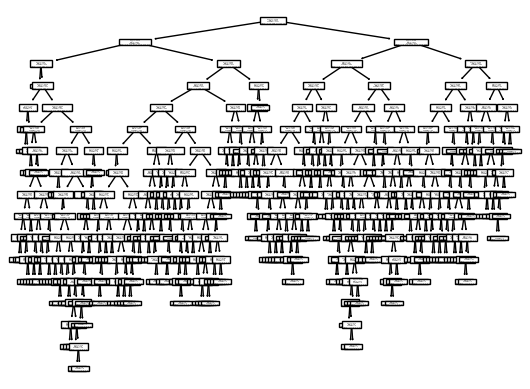

In [106]:
plot_tree(arbol)

In [107]:
predicciones = arbol.predict(X_test)

In [108]:
predicciones

array([6, 7, 5, 6, 5, 5, 5, 6, 6, 4, 6, 7, 6, 5, 5, 5, 6, 6, 5, 6, 6, 5,
       6, 6, 5, 4, 5, 7, 6, 5, 6, 6, 6, 6, 6, 7, 5, 5, 5, 6, 5, 4, 6, 4,
       5, 6, 6, 6, 5, 6, 7, 5, 5, 5, 5, 6, 8, 6, 6, 5, 6, 6, 5, 6, 5, 6,
       5, 5, 6, 6, 5, 8, 5, 6, 5, 6, 6, 6, 5, 6, 6, 4, 5, 7, 5, 4, 6, 5,
       6, 6, 6, 6, 5, 6, 7, 6, 6, 7, 6, 5, 5, 7, 7, 7, 6, 6, 5, 5, 5, 6,
       5, 6, 4, 6, 5, 7, 7, 6, 6, 5, 5, 7, 4, 6, 6, 4, 6, 5, 5, 5, 6, 5,
       5, 6, 8, 5, 6, 7, 7, 3, 6, 8, 6, 5, 5, 5, 5, 7, 6, 6, 6, 5, 5, 5,
       6, 6, 6, 6, 6, 5, 6, 6, 6, 5, 6, 6, 6, 7, 6, 6, 6, 5, 7, 5, 7, 7,
       4, 5, 6, 6, 6, 7, 6, 6, 6, 5, 7, 5, 6, 5, 5, 6, 6, 5, 6, 6, 5, 5,
       7, 5, 7, 5, 5, 6, 7, 5, 6, 5, 6, 6, 6, 5, 5, 5, 7, 7, 6, 5, 5, 5,
       7, 6, 5, 5, 5, 5, 5, 7, 5, 6, 6, 7, 6, 6, 5, 7, 6, 5, 5, 6, 5, 6,
       7, 5, 5, 6, 5, 6, 6, 5, 5, 5, 7, 5, 6, 6, 6, 6, 6, 5, 5, 4, 6, 7,
       6, 5, 7, 6, 4, 5, 6, 5, 5, 6, 6, 6, 5, 6, 5, 5, 5, 7, 6, 6, 6, 6,
       5, 6, 6, 6, 5, 6, 6, 5, 5, 5, 8, 7, 6, 6, 5,

In [78]:
# Examinamos la matriz de confusión
pd.crosstab(np.array([Y[0] for y in Y_test.values.tolist()]), predicciones, rownames=['Actual'], colnames=['Predicciones'])

Predicciones,3,4,5,6,7,8
Actual,,,,,,
5,1,9,164,153,51,3


In [80]:
# Desempeño del modelo de regresión

print(classification_report(Y_test,predicciones))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        13
           5       0.66      0.69      0.68       156
           6       0.58      0.57      0.57       157
           7       0.49      0.52      0.51        48
           8       0.33      0.25      0.29         4

    accuracy                           0.59       381
   macro avg       0.34      0.34      0.34       381
weighted avg       0.57      0.59      0.58       381



In [81]:
accuracy = accuracy_score(Y_test,predicciones)
accuracy

0.5853018372703412

In [83]:
precision = precision_score(Y_test, predicciones, average='weighted')
precision

0.5745964561699037

In [84]:
recall = recall_score(Y_test, predicciones, average='weighted')
recall

0.5853018372703412

In [86]:
f1 = f1_score(Y_test, predicciones, average='weighted')
f1

0.5796159277744242

### 7. Realizar las diferentes gráficas que permitan visualizar los resultados del modelo

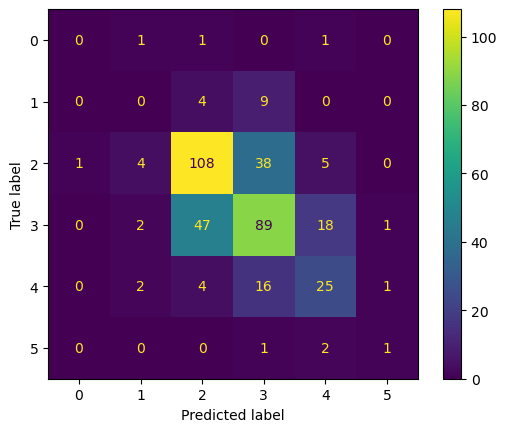

In [87]:
#Matrix de Confusión del modelo

cm=confusion_matrix(Y_test,predicciones)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

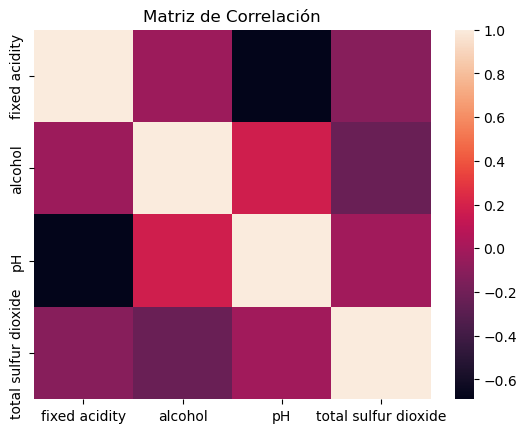

In [92]:
sns.heatmap(corr)
plt.title('Matriz de Correlación')
plt.show()

<Axes: xlabel='fixed acidity', ylabel='alcohol'>

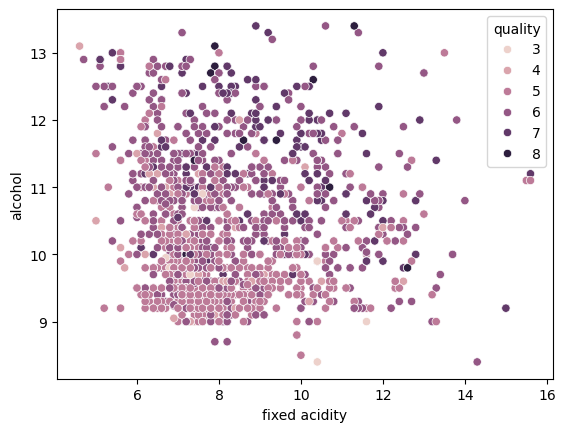

In [95]:
sns.scatterplot(x = "fixed acidity", y = "alcohol", hue = "quality", data = Datos)

### 8. Interpretar, analizar y documentar los resultados obtenidos

Del desempeño del modelo se puede describir:

Precisión: Precisión mide la proporción de predicciones positivas verdaderas entre todas las predicciones positivas realizadas por el modelo. Aquí la precisión para la clase "quality" es 0,57, lo que significa que el 57% de los predichos como enfermos por el modelo eran en realidad enfermos cardiacos.

Recall: Mide la proporción de predicciones positivas verdaderas entre todas las instancias positivas reales en el conjunto de datos. Aquí el Recall para la clase "quality" es 0,58, lo que indica que el modelo identificó correctamente al 58% de todos los enfermos cardiacos.

F1 Score: Es la media armónica de precisión y recall. Proporciona una puntuación única que equilibra la precisión y recall. Aquí la puntuación F1 para la clase "condition" es 0,57, lo que indica un equilibrio entre precisión y recall.

De la Matriz de Confusión podemos interpretar:

Verdaderos negativos: el recuento de observaciones que un clasificador predijo correctamente como falso 108

Verdaderos positivos: el recuento de observaciones que un clasificador predijo correctamente como Verdadero 89

Falsos positivos: el recuento de observaciones que un clasificador predijo incorrectamente como Verdaderas 38

Falsos negativos: el recuento de observaciones que un clasificador predijo incorrectamente como falso 47

De la curva de precisión del modelo se puede interpretar:

El AUC es 0,85 lo que significa que el 85% de las predicciones del clasificador son correctas en todos los umbrales de clasificación.